In [2]:
import numpy as np
import sympy as sp
import control as ct
import matplotlib.pyplot as plt
import scipy.signal
import scipy.linalg
import cvxpy as cp
from sympy.physics.mechanics import dynamicsymbols

In [3]:
t = sp.Symbol('t')
x, th1, th2 = dynamicsymbols('x theta1 theta2')
u = sp.Symbol('u')
M, m1, m2, L1, L2, g = sp.symbols('M m1 m2 L1 L2 g', positive=True)
delta, c1, c2 = sp.symbols('delta c1 c2', nonnegative=True)

q = sp.Matrix([x, th1, th2])
qd = q.diff(t)
qdd = qd.diff(t)

In [4]:
p0 = sp.Matrix([x, 0])                                        # cart
p1 = p0 + L1 * sp.Matrix([sp.sin(th1),  sp.cos(th1)])          # mass 1
p2 = p1 + L2 * sp.Matrix([sp.sin(th2),  sp.cos(th2)])          # mass 2
 
v0, v1, v2 = p0.diff(t), p1.diff(t), p2.diff(t)

In [5]:
T = sp.Rational(1, 2) * (M * v0.dot(v0) + m1 * v1.dot(v1) + m2 * v2.dot(v2))
V = g * (m1 * p1[1] + m2 * p2[1])
T, V = sp.simplify(T), sp.simplify(V)
Lag = T - V

In [6]:
Q = sp.Matrix([u - delta * x.diff(t),          # actuator + cart friction
               -c1 * th1.diff(t),              # joint damping (0 by default)
               -c2 * th2.diff(t)])
 
EL = sp.Matrix([sp.diff(Lag, qd[i], t) - sp.diff(Lag, q[i]) - Q[i]
                for i in range(3)])
EL = sp.simplify(sp.trigsimp(EL))

In [7]:
D, rhs = sp.linear_eq_to_matrix(EL, list(qdd))   # D*qdd = rhs
D = sp.simplify(D)
rhs = sp.simplify(rhs)

G = sp.simplify(sp.Matrix([sp.diff(V, q[i]) for i in range(3)]))
CqdG = sp.simplify(-rhs + Q)          # = C(q,qd)*qd + G(q)
Cqd = sp.simplify(CqdG - G)

In [8]:
acc = sp.simplify(D.LUsolve(rhs))

In [9]:
xs, t1s, t2s, dxs, dt1s, dt2s = sp.symbols('x_ th1_ th2_ dx_ dth1_ dth2_')
sub_map = {x.diff(t): dxs, th1.diff(t): dt1s, th2.diff(t): dt2s,
           x: xs, th1: t1s, th2: t2s}
 
X = sp.Matrix([xs, t1s, t2s, dxs, dt1s, dt2s])
f = sp.Matrix([dxs, dt1s, dt2s,
               *[a.subs(sub_map) for a in acc]])

A_sym = f.jacobian(X)
B_sym = f.jacobian(sp.Matrix([u]))
 
up = {xs: 0, t1s: 0, t2s: 0, dxs: 0, dt1s: 0, dt2s: 0, u: 0}   # upright
A_up = sp.simplify(A_sym.subs(up))
B_up = sp.simplify(B_sym.subs(up))
 
down = {xs: 0, t1s: sp.pi, t2s: sp.pi, dxs: 0, dt1s: 0, dt2s: 0, u: 0}
A_dn = sp.simplify(A_sym.subs(down))
B_dn = sp.simplify(B_sym.subs(down))


In [10]:
params = {M : 10, m1 : 1, m2 : 1, L1 : 0.5, L2 : 0.5, delta : 1, g : 10, c1 : 0.001, c2 : 0.001}

A = A_up.subs(params)
B = B_up.subs(params)

A = np.array(A).astype(np.float64)
B = np.array(B).astype(np.float64)

dt = 0.1

sys = scipy.signal.StateSpace(A,B,np.eye(6),np.zeros((6,1)))
sysd = sys.to_discrete(dt)

Ad = sysd.A
Bd = sysd.B
Cd = sysd.C
Dd = sysd.D

Qlqr = np.diag([1,1,1,1,1,1])
Rlqr = np.array([[0.01]])
u_max = 60.0

K, P, E = ct.dlqr(Ad, Bd, Qlqr, Rlqr)

Tau = 100
n = 6
nu = 1
MPC = 10

f_num = sp.lambdify((xs, t1s, t2s, dxs, dt1s, dt2s, u), f.subs(params), 'numpy')

initial_state = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
state = initial_state.copy()
goal_state = np.array([1.0, 0.0, 0.0, 0.0, 0.0, 0.0])

states = np.zeros((Tau+1, n))
controls = np.zeros((Tau, nu))
states[0] = state

In [11]:
for k in range(Tau):

    xs = cp.Variable((MPC+1, n))
    us = cp.Variable((MPC, nu))

    objective = 0
    constraints = [xs[0] == state - goal_state]

    for t in range(MPC):
        objective += (cp.quad_form(xs[t], Qlqr) + cp.quad_form(us[t],Rlqr))
        constraints += [xs[t+1] == Ad @ xs[t] + Bd @ us[t]]
        constraints += [cp.abs(us[t]) <= u_max]

    objective += cp.quad_form(xs[MPC], P)

    problem = cp.Problem(cp.Minimize(objective), constraints)
    problem.solve()

    u_k = us.value[0]
    controls[k] = u_k

    state = goal_state + Ad @ (state - goal_state) + Bd @ u_k 
    states[k+1] = state


x_hist = states.copy()
u_hist = controls.copy()
t_hist = np.arange(0, Tau*dt + dt, dt)

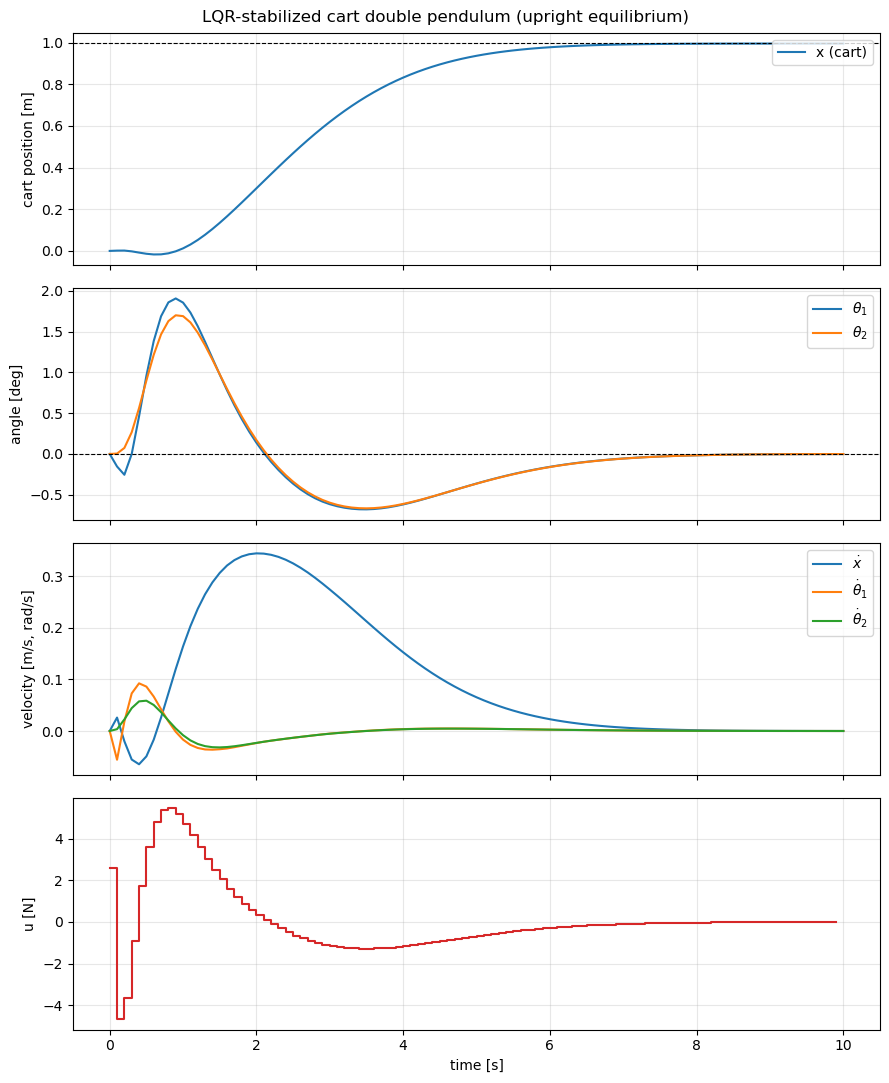

In [12]:
fig, axs = plt.subplots(4, 1, figsize=(9, 11), sharex=True)

# --- cart position ---
axs[0].plot(t_hist, x_hist[:, 0], label='x (cart)')
axs[0].axhline(goal_state[0], color='k', lw=0.8, ls='--')
axs[0].set_ylabel('cart position [m]')
axs[0].legend(loc='upper right')
axs[0].grid(alpha=0.3)

# --- pendulum angles, in degrees for readability ---
axs[1].plot(t_hist, np.degrees(x_hist[:, 1]), label=r'$\theta_1$')
axs[1].plot(t_hist, np.degrees(x_hist[:, 2]), label=r'$\theta_2$')
axs[1].axhline(0, color='k', lw=0.8, ls='--')
axs[1].set_ylabel('angle [deg]')
axs[1].legend(loc='upper right')
axs[1].grid(alpha=0.3)

# --- velocities ---
axs[2].plot(t_hist, x_hist[:, 3], label=r'$\dot x$')
axs[2].plot(t_hist, x_hist[:, 4], label=r'$\dot\theta_1$')
axs[2].plot(t_hist, x_hist[:, 5], label=r'$\dot\theta_2$')
axs[2].set_ylabel('velocity [m/s, rad/s]')
axs[2].legend(loc='upper right')
axs[2].grid(alpha=0.3)

# --- control effort ---
axs[3].step(t_hist[:-1], u_hist, where='post', color='tab:red')
axs[3].set_ylabel('u [N]')
axs[3].set_xlabel('time [s]')
axs[3].grid(alpha=0.3)

fig.suptitle('LQR-stabilized cart double pendulum (upright equilibrium)')
fig.tight_layout()
plt.show()